# SETUP

In [11]:
#config
import json
from pathlib import Path
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import sys

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir, agent_p_output_dir,
    set_pass, pass_num, asset_name
)
from Eval_defs import importance_votes,consensus_spans, random_baseline_closed_form,random_baseline_blocks, load_labels,paper_edit_to_timegrid,score_paper_vs_GT_edits,labels_dir,cut_csv_to_timegrid, time_grid,spans_to_mask, annotator_beats_to_grid   # now resolvable
 


case_name =  "205_copper_05"
experiment = "Pipe_eval_01"
set_case(case_name, experiment)
paper_edit_json_path = agent_p_output_dir() / f"{case_name}_{experiment}_1_revision.json"
ablation = "ablation_01"
ablation_paper_edit_json_path = case_dir() / "012_agent_p_output"/ ablation / f"{case_name}_{ablation}_1_revision.json"
GT_paper_edit_json_path =  case_dir() / "100_labels" / f"{case_name}_cuts_GT_paper_edit.json"

my_cut_csv = labels_dir() / f"{case_name}_cuts.csv"
BIN_S = 1.0      # vote grid, seconds. 0.1 matches the label precision if you want it finer
WEIGHTS = None   # or {"important": 1.0, "critical": 2.0}


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# MY CUT
## VS machine

In [12]:
#from Eval_defs import GT_paper_edit
#for case in ["205_copper_05"]:
#    GT_paper_edit(case)


In [13]:
edges = time_grid(case_name, bin_s=BIN_S, labels=None, tol_s=1.0)
machine_paper_edit = paper_edit_to_timegrid(paper_edit_json_path, case_name, edges)
ablation_paper_edit = paper_edit_to_timegrid(ablation_paper_edit_json_path, case_name, edges)

GT_edit = cut_csv_to_timegrid(my_cut_csv, edges)   # w, 0 or 1
#beta controls f_beta wihc controls soft f1
score_paper_vs_GT_edits(GT_edit, machine_paper_edit)
#f beta is precision and recall together. the F measure
#f-1 is beta =1 same calc but hard coded



205_copper_05: 2/5 beats have no resolved frames — skipped


205_copper_05: 1/7 beats have no resolved frames — skipped


{'soft_precision': 0.8424657534246576,
 'precision': 0.7808219178082192,
 'soft_recall': 0.9104477611940298,
 'recall': 0.8507462686567164,
 'soft_specificity': 0.9065040650406504,
 'specificity': 0.8699186991869918,
 'iou': 0.6867469879518072,
 'soft_f1': 0.8751385081938531,
 'f_beta': 0.8142857142857143,
 'beta': 1.0,
 'decay_s': 4.0,
 'true_p_s': 57.0,
 'false_p_s': 16.0,
 'false_n_s': 10.0,
 'true_n_s': 107.0,
 'edit_s': 73.0,
 'gt_s': 67.0,
 'len_ratio': 1.0895522388059702,
 'n_segments': 2,
 'shortest_seg_s': 36.0,
 'median_seg_s': 36.5}

# VS humans

[{'schema_version': 4, 'case_name': '205', 'category': 'EGO_POLICE', 'annotator': 'Tamara', 'brief': 'Select the moments needed for an accurate, to-the-point account of what happened in this incident.', 'annotated_at': '2026-08-26T15:17:38.484Z', 'status': 'complete', 'video_duration_sec': 189.205, 'time_spent_sec': 750, 'max_watched_sec': 189.2, 'overall': {'feelings': ['tense', 'upsetting'], 'pacing': 'too_long'}, 'subjects': [{'id': 'smta8eh01_1', 'category': 'person', 'name': '', 'descriptor': 'Police officer recording the footage', 'label': 'person_1'}, {'id': 'smta8f7qx_3', 'category': 'person', 'name': '', 'descriptor': 'Black man with longer dark hair, wearing a blue cap.', 'label': 'person_2'}, {'id': 'smta8lnl2_8', 'category': 'person', 'name': '', 'descriptor': 'Uniformed police officers', 'label': 'person_3'}], 'beats': [{'start_sec': 115.1, 'end_sec': 119.8, 'event_category': 'important', 'tracked_subject_ids': ['smta8eh01_1']}, {'start_sec': 119.8, 'end_sec': 124.5, 'even

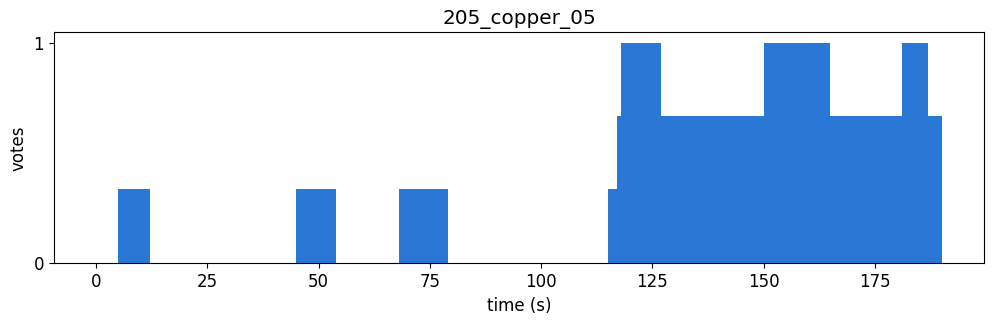

In [14]:
import matplotlib.pyplot as plt
vote_curve, majority_spans, rows = {}, {}, []

labels = load_labels()
print(labels)
edges, votes = importance_votes(labels, weights=WEIGHTS)
n_ann = len(labels)
vote_curve = (edges, votes)
majority_spans = consensus_spans(edges, votes, n_ann / 2 + 1e-9)
rows.append(dict(
    case=case_name,
    annotators=n_ann,
    names="/".join(sorted(l["annotator"] for l in labels)),
    dur_s=edges[-1],
    any_s=float((votes >= 1).sum() * BIN_S),
    majority_s=float((votes > n_ann / 2).sum() * BIN_S),
    unanimous_s=float((votes == n_ann).sum() * BIN_S),
    n_spans=len(majority_spans),
    ))

import matplotlib.pyplot as plt
edges, votes = vote_curve

fig, ax = plt.subplots(figsize=(12, 3))
ax.stairs(votes, edges, fill=True, color="#2a78d6")
ax.set_xlabel("time (s)")
ax.set_ylabel("votes")
ax.set_yticks(range(int(votes.max()) + 1))
ax.set_title(case_name)
plt.show()

saved /workspace/project/writing/Figures/sys_eval/205_copper_05_edit_overlaps.pdf


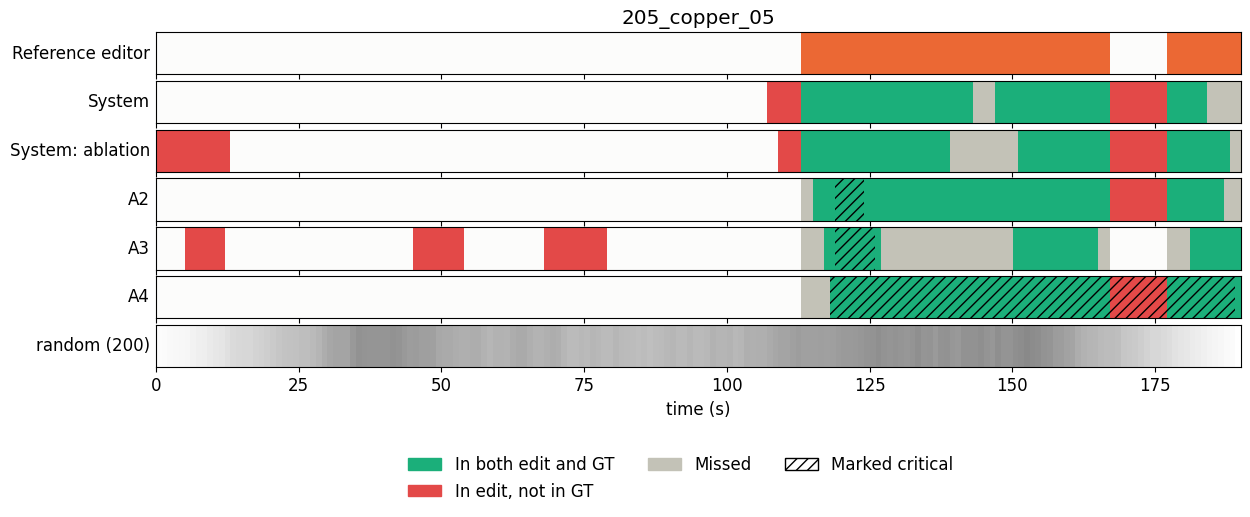

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from Eval_defs import timeline_agreement
TP_C, FP_C, FN_C, REF_C = "#1baf7a", "#e34948", "#c3c2b7", "#eb6834"


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

tracks = {"ME (GT)": GT_edit, "machine": machine_paper_edit, "System: ablation" : ablation_paper_edit}
for l in load_labels():
    tracks[l["annotator"]] = annotator_beats_to_grid(l, edges)
rand_row, null_stats, density = random_baseline_blocks(GT_edit, machine_paper_edit)
tracks["random (200)"] = density
timeline_agreement(case_name, edges, tracks, GT_edit=GT_edit,
                   fname=f"{asset_name()}_edit_overlaps.pdf")


In [16]:
decay_s=4
rows = [dict(editor="GT", time_min=70.0,
             **score_paper_vs_GT_edits(GT_edit, GT_edit, decay_s=decay_s))]

rows.append(dict(editor="machine", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, machine_paper_edit, decay_s=decay_s)))
rows.append(dict(editor="System: ablation", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, ablation_paper_edit, decay_s=decay_s)))
for l in load_labels():
    rows.append(dict(editor=l["annotator"],
                     time_min=round(l["time_spent_sec"] / 60, 1),
                     **score_paper_vs_GT_edits(GT_edit, annotator_beats_to_grid(l, edges), decay_s=decay_s)))
rand_row, null_stats, density = random_baseline_blocks(GT_edit, machine_paper_edit)
rows.append(rand_row)
rows.append(dict(editor="whole clip", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, np.ones_like(GT_edit), decay_s=decay_s)))
comp = pd.DataFrame(rows)
comp[["editor", "edit_s" , "soft_f1",
      
      "soft_precision", 
      "soft_recall", 
      "soft_specificity", 
      "iou", "len_ratio", "n_segments", "median_seg_s","time_min" ]].round(3)



,editor,edit_s,soft_f1,soft_precision,soft_recall,soft_specificity,iou,len_ratio,n_segments,median_seg_s,time_min
0,GT,67.0,1.000,1.000,1.000,1.000,1.000,1.000,2.00,33.500,70.0
1,machine,73.0,0.875,0.842,0.910,0.907,0.687,1.090,2.00,36.500,NaN
2,System: ablation,80.0,0.781,0.719,0.854,0.817,0.564,1.194,3.00,30.000,NaN
3,Tamara,72.0,0.934,0.903,0.966,0.943,0.805,1.075,1.00,72.000,12.5
4,Vuk,61.0,0.585,0.557,0.616,0.780,0.362,0.910,6.00,9.500,9.3
5,stefanos,72.0,0.925,0.903,0.948,0.943,0.805,1.075,1.00,72.000,1.6
6,"random (blocks, n=200)",73.0,0.424,0.403,0.448,0.646,0.264,1.090,1.99,36.865,NaN
7,whole clip,190.0,0.547,0.376,1.000,0.037,0.353,2.836,1.00,190.000,NaN


In [17]:
null_stats

,Producer_agent_score,mean,p05,p95,pct
iou,0.687,0.264,0.000,0.489,99.0
soft_f1,0.875,0.424,0.000,0.721,99.0
precision,0.781,0.381,0.000,0.630,99.0
recall,0.851,0.415,0.000,0.687,99.0
specificity,0.870,0.633,0.407,0.780,99.0


In [18]:
cols = ["editor", "time_min", "edit_s", "len_ratio",
        "soft_f1", "soft_precision", "soft_recall", "soft_specificity",
        "iou", "n_segments", "median_seg_s"]

nice = {"editor": "Editor", "time_min": "Time (min)", "edit_s": "Cut (s)",
        "len_ratio": "Len ratio", "soft_f1": "Soft $F_1$",
        "soft_precision": "Soft prec.", "soft_recall": "Soft rec.",
        "soft_specificity": "Soft spec.", "iou": "IoU",
        "n_segments": "Shots", "median_seg_s": "Median shot (s)"}

(comp[cols].rename(columns=nice)
 .to_latex(project_root / "writing" /"Figures" / "sys_eval"/ f"{case_name}_{experiment}_table_comp.tex",
           index=False, escape=False, float_format="%.3f",
           column_format="lrrrrrrrrrr",
           caption=f"Editors scored against the reference cut, {case_name}",
           label="tab:noodles_comp",
           position="htbp"))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
saved /workspace/project/writing/Figures/sys_eval/205_copper_05_map_beats.png


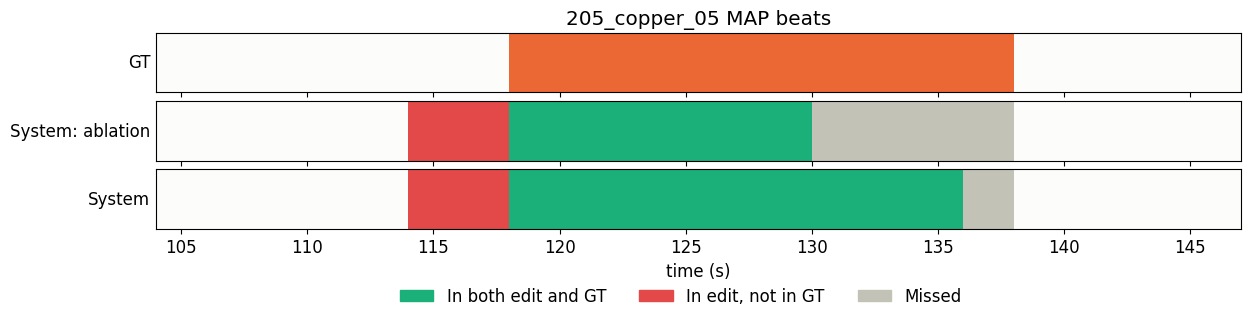

,editor,GT subjects,Subjects,Shared,Total,Overlap s,Span IoU
0,System: ablation,3,2,2,3,12,0.50
1,System,3,2,1,4,18,0.75


In [24]:
%load_ext autoreload
%autoreload 2
from Eval_defs import GT_paper_edit, compare_map_beats, paper_edit_path


map_df = compare_map_beats(GT_paper_edit_json_path,
                           (ablation_paper_edit_json_path, paper_edit_json_path),
                           label_a="GT", label_b=("System: ablation","System"),
                           case_name=case_name, fname=f"{case_name}_map_beats.png")

map_df


In [25]:
from Eval_defs import repeated_frame_counts, repeated_frame_pairs
repeated_frame_counts(ablation_paper_edit_json_path)
repeated_frame_pairs(ablation_paper_edit_json_path)


Repeated frames 151 
 total frames 2337 
 %repeated: 6.4612751390671805


[('beat-02', 'beat-03', 32),
 ('beat-03', 'beat-04', 87),
 ('beat-07', 'beat-06', 32)]